# 02 · Regresión logística

## Objetivo

En este notebook vamos a construir y entender un modelo de **regresión logística** usando un ejemplo sintético inspirado en ATM.

Supongamos que queremos estimar si una ventana operativa de 15 minutos tendrá una **situación de alta carga de coordinación**.

El target será binario:

- `0`: carga normal
- `1`: alta carga

Usaremos inicialmente una sola variable:

- `flights_15min`: número de vuelos en la ventana

El objetivo es comprender:

- por qué la regresión logística es un modelo de clasificación;
- qué es la función sigmoide;
- qué significa que el modelo produzca una probabilidad;
- qué papel juega el umbral de decisión;
- cómo interpretar coeficientes;
- cómo evaluar un clasificador;
- qué son accuracy, precision, recall y F1;
- cómo leer una matriz de confusión;
- y por qué elegir el umbral depende del problema.


## 1. Importaciones


In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


Python: 3.14.7
NumPy: 2.5.3
Pandas: 3.0.6


## 2. Crear un conjunto de datos ATM sintético

Generaremos ventanas de 15 minutos con distinto número de vuelos.

La probabilidad de alta carga aumentará con el tráfico, pero no de forma determinista.

Esto es importante: para un mismo número de vuelos puede haber ventanas normales y ventanas de alta carga, porque en un sistema real influirían también otros factores.

Para este ejercicio simplificaremos todo eso en ruido probabilístico.


In [2]:
rng = np.random.default_rng(42)

n_samples = 300
flights_15min = rng.integers(5, 36, size=n_samples)

# La transición importante ocurre aproximadamente alrededor de 20 vuelos.
logit = -8.0 + 0.40 * flights_15min
prob_high_load = 1 / (1 + np.exp(-logit))

high_load = rng.binomial(1, prob_high_load)

df = pd.DataFrame({
    "flights_15min": flights_15min,
    "high_load": high_load
})

df.head()


,flights_15min,high_load
0,7,0
1,28,1
2,25,1
3,18,0
4,18,0


## 3. Explorar los datos


In [3]:
df.describe()


,flights_15min,high_load
count,300.000000,300.000000
mean,19.956667,0.486667
std,8.454172,0.500657
min,5.000000,0.000000
25%,13.000000,0.000000
50%,20.000000,0.000000
75%,27.000000,1.000000
max,35.000000,1.000000


In [4]:
df["high_load"].value_counts().sort_index()


high_load
0    154
1    146
Name: count, dtype: int64

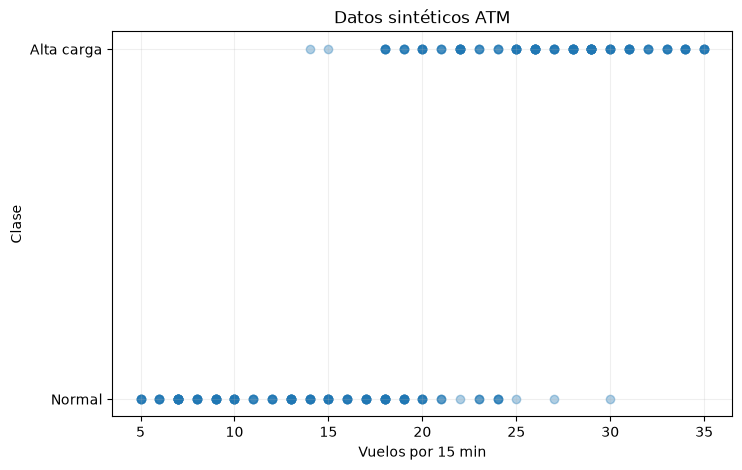

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["flights_15min"], df["high_load"], alpha=0.35)
plt.yticks([0, 1], ["Normal", "Alta carga"])
plt.xlabel("Vuelos por 15 min")
plt.ylabel("Clase")
plt.title("Datos sintéticos ATM")
plt.grid(alpha=0.2)
plt.show()


## 4. ¿Por qué no usar una regresión lineal?

La regresión logística parte de una combinación lineal:

$$
z = b + wx
$$

pero transforma esa salida mediante la función sigmoide:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

La sigmoide siempre produce valores entre 0 y 1, por lo que podemos interpretarlos como probabilidades.


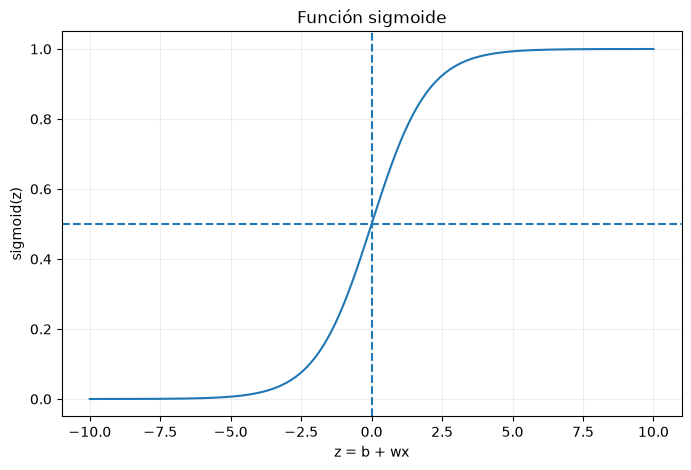

In [6]:
z = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("z = b + wx")
plt.ylabel("sigmoid(z)")
plt.title("Función sigmoide")
plt.grid(alpha=0.2)
plt.show()


## 5. Separar `X` e `y`


In [7]:
X = df[["flights_15min"]]
y = df["high_load"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (300, 1)
Forma de y: (300,)


## 6. Train / test split

Usaremos 80 % para entrenamiento y 20 % para test.

`stratify=y` ayuda a mantener una proporción de clases similar en ambos conjuntos.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape[0], "muestras")
print("Test :", X_test.shape[0], "muestras")
print("Proporción positiva train:", round(y_train.mean(), 3))
print("Proporción positiva test :", round(y_test.mean(), 3))


Train: 240 muestras
Test : 60 muestras
Proporción positiva train: 0.488
Proporción positiva test : 0.483


## 7. Entrenar la regresión logística


In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [10]:
intercept = model.intercept_[0]
coef = model.coef_[0][0]

print(f"Intercepto: {intercept:.4f}")
print(f"Coeficiente: {coef:.4f}")
print(f"Odds ratio por vuelo adicional: {np.exp(coef):.3f}")


Intercepto: -9.3720
Coeficiente: 0.4672
Odds ratio por vuelo adicional: 1.595


El coeficiente no representa directamente un cambio en probabilidad.

La regresión logística modela:

$$
\log\left(\frac{p}{1-p}\right)=b+wx
$$

Por eso, `exp(coeficiente)` se interpreta como un **odds ratio**.


## 8. Obtener probabilidades


In [11]:
probabilities = model.predict_proba(X_test)
p_high_load = probabilities[:, 1]

results = pd.DataFrame({
    "flights_15min": X_test["flights_15min"].to_numpy(),
    "actual": y_test.to_numpy(),
    "p_high_load": p_high_load
})

results.head(10)


,flights_15min,actual,p_high_load
0,18,0,0.276230
1,15,0,0.085905
2,18,0,0.276230
3,19,0,0.378460
4,13,0,0.035606
5,19,0,0.378460
6,28,1,0.976067
7,18,0,0.276230
8,34,1,0.998515
9,14,0,0.055627


## 9. Convertir probabilidad en clase

Por defecto, `scikit-learn` usa un umbral de 0.5:

- si `P(y=1) >= 0.5` → clase 1
- si `P(y=1) < 0.5` → clase 0


In [12]:
y_pred = model.predict(X_test)
results["predicted"] = y_pred
results.head(10)


,flights_15min,actual,p_high_load,predicted
0,18,0,0.276230,0
1,15,0,0.085905,0
2,18,0,0.276230,0
3,19,0,0.378460,0
4,13,0,0.035606,0
5,19,0,0.378460,0
6,28,1,0.976067,1
7,18,0,0.276230,0
8,34,1,0.998515,1
9,14,0,0.055627,0


## 10. Visualizar la curva logística


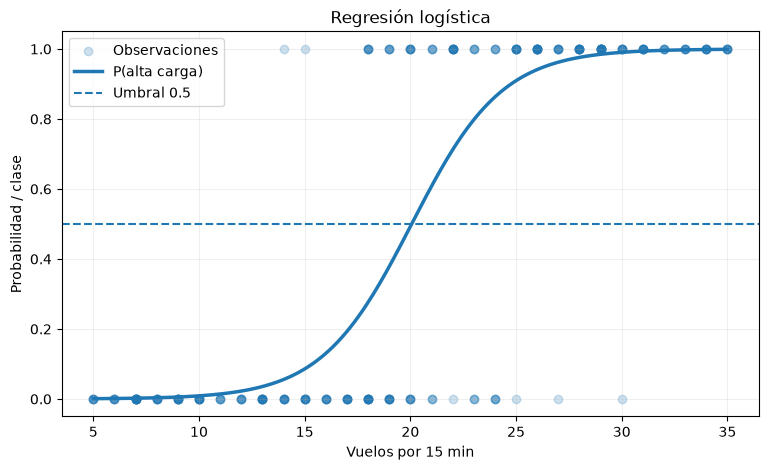

In [13]:
x_line = np.linspace(df["flights_15min"].min(), df["flights_15min"].max(), 300)
x_line_df = pd.DataFrame({"flights_15min": x_line})
p_line = model.predict_proba(x_line_df)[:, 1]

plt.figure(figsize=(9, 5))
plt.scatter(df["flights_15min"], df["high_load"], alpha=0.22, label="Observaciones")
plt.plot(x_line, p_line, linewidth=2.5, label="P(alta carga)")
plt.axhline(0.5, linestyle="--", label="Umbral 0.5")
plt.xlabel("Vuelos por 15 min")
plt.ylabel("Probabilidad / clase")
plt.title("Regresión logística")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 11. Frontera de decisión


In [14]:
decision_boundary = -intercept / coef
print(f"Frontera aproximada con umbral 0.5: {decision_boundary:.2f} vuelos")


Frontera aproximada con umbral 0.5: 20.06 vuelos


La frontera aparece donde:

$$
P(y=1)=0.5
$$

y, por tanto:

$$
b+wx=0
$$


## 12. Métricas de clasificación


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1       : {f1:.3f}")


Accuracy : 0.900
Precision: 0.871
Recall   : 0.931
F1       : 0.900


- **Accuracy**: proporción total de aciertos.
- **Precision**: de los casos predichos como positivos, cuántos eran realmente positivos.
- **Recall**: de todos los positivos reales, cuántos detectamos.
- **F1**: combina precision y recall.

La accuracy puede ser engañosa si las clases están muy desbalanceadas.


## 13. Matriz de confusión


In [16]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[27,  4],
       [ 2, 27]])

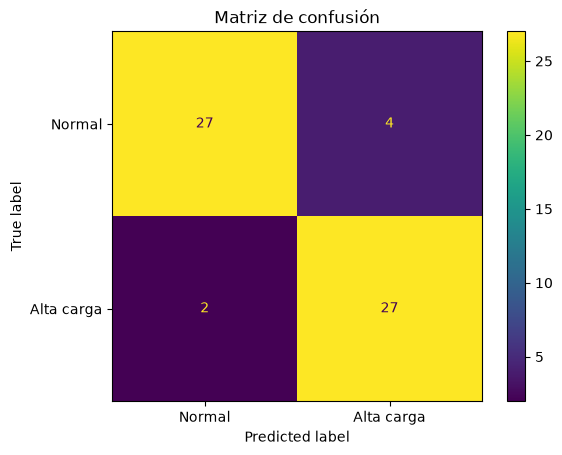

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Alta carga"]
)
disp.plot()
plt.title("Matriz de confusión")
plt.show()


Para la clase positiva `1 = alta carga`:

- **TP**: alta carga predicha y real;
- **TN**: normal predicho y real;
- **FP**: alarma que finalmente no correspondía a alta carga;
- **FN**: no se detectó una situación que realmente era de alta carga.


In [18]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Alta carga"]
))


              precision    recall  f1-score   support

      Normal       0.93      0.87      0.90        31
  Alta carga       0.87      0.93      0.90        29

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



## 14. El umbral de 0.5 no es una ley

Si queremos evitar especialmente falsos negativos, podemos bajar el umbral.

Eso suele aumentar el recall, a costa de generar más falsos positivos.


In [19]:
threshold = 0.30
y_pred_030 = (p_high_load >= threshold).astype(int)

print("Umbral:", threshold)
print("Accuracy :", round(accuracy_score(y_test, y_pred_030), 3))
print("Precision:", round(precision_score(y_test, y_pred_030), 3))
print("Recall   :", round(recall_score(y_test, y_pred_030), 3))
print("F1       :", round(f1_score(y_test, y_pred_030), 3))


Umbral: 0.3
Accuracy : 0.833
Precision: 0.757
Recall   : 0.966
F1       : 0.848


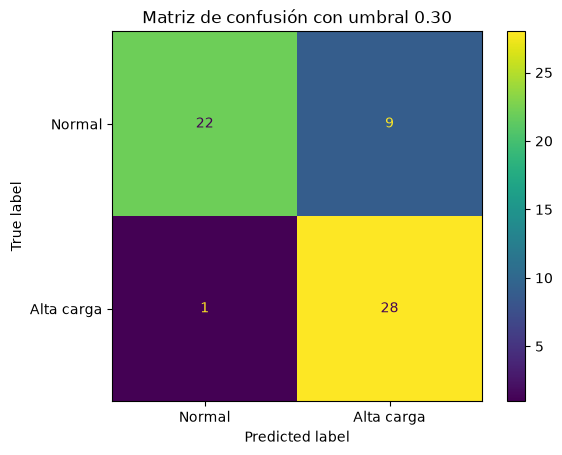

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_030,
    display_labels=["Normal", "Alta carga"]
)
plt.title("Matriz de confusión con umbral 0.30")
plt.show()


## 15. Comparar varios umbrales


In [21]:
thresholds = np.arange(0.1, 1.0, 0.1)
rows = []

for threshold in thresholds:
    pred = (p_high_load >= threshold).astype(int)

    rows.append({
        "threshold": round(float(threshold), 1),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    })

threshold_metrics = pd.DataFrame(rows)
threshold_metrics


,threshold,accuracy,precision,recall,f1
0,0.1,0.750000,0.659091,1.000000,0.794521
1,0.2,0.750000,0.659091,1.000000,0.794521
2,0.3,0.833333,0.756757,0.965517,0.848485
3,0.4,0.866667,0.818182,0.931034,0.870968
4,0.5,0.900000,0.870968,0.931034,0.900000
5,0.6,0.900000,0.870968,0.931034,0.900000
6,0.7,0.883333,0.866667,0.896552,0.881356
7,0.8,0.800000,0.869565,0.689655,0.769231
8,0.9,0.816667,0.909091,0.689655,0.784314


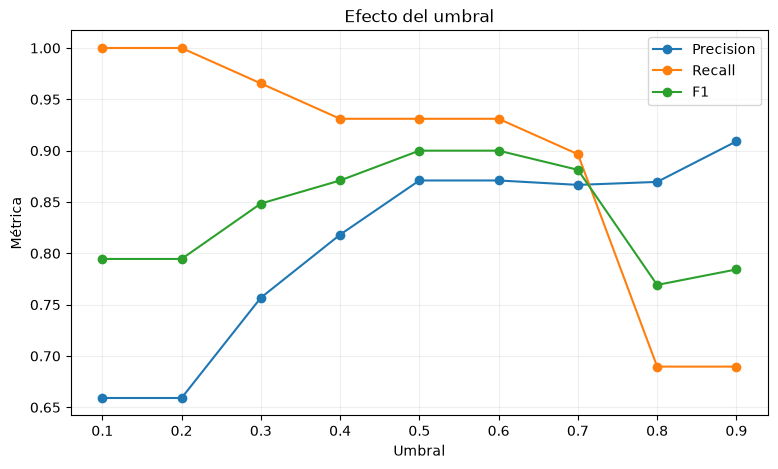

In [22]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_metrics["threshold"], threshold_metrics["precision"], marker="o", label="Precision")
plt.plot(threshold_metrics["threshold"], threshold_metrics["recall"], marker="o", label="Recall")
plt.plot(threshold_metrics["threshold"], threshold_metrics["f1"], marker="o", label="F1")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.title("Efecto del umbral")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 16. Curva ROC y AUC


In [23]:
fpr, tpr, roc_thresholds = roc_curve(y_test, p_high_load)
auc = roc_auc_score(y_test, p_high_load)

print(f"ROC AUC: {auc:.3f}")


ROC AUC: 0.948


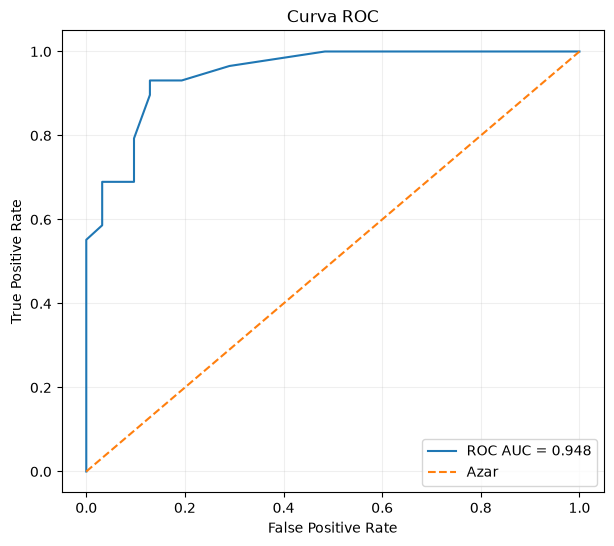

In [24]:
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 17. Probar valores nuevos


In [25]:
new_windows = pd.DataFrame({
    "flights_15min": [10, 15, 20, 25, 30]
})

new_probabilities = model.predict_proba(new_windows)[:, 1]

pd.DataFrame({
    "flights_15min": new_windows["flights_15min"],
    "p_high_load": new_probabilities
})


,flights_15min,p_high_load
0,10,0.009009
1,15,0.085905
2,20,0.492766
3,25,0.909440
4,30,0.990459


## 18. Limitación del modelo

Aquí usamos una sola feature:

```text
flights_15min
```

pero la complejidad ATM real depende de muchas variables.

Con varias features, la parte lineal sería:

$$
z=b+w_1x_1+w_2x_2+...+w_nx_n
$$

y después aplicaríamos exactamente la misma sigmoide.


# 19. Ejercicios

### Ejercicio 1
Calcula manualmente la probabilidad de alta carga para 20 vuelos:

```python
z = intercept + coef * 20
p = 1 / (1 + np.exp(-z))
```

Comprueba que coincide con `predict_proba()`.

### Ejercicio 2
Prueba los umbrales `0.2`, `0.4`, `0.6` y `0.8`.

Observa cómo cambian falsos positivos, falsos negativos, precision y recall.

### Ejercicio 3
Imagina que el modelo alimenta una alerta preventiva ATM.

¿Qué error sería más costoso: un falso positivo o un falso negativo?

### Ejercicio 4
Genera clases muy desbalanceadas y comprueba por qué `accuracy` deja de ser suficiente.

### Ejercicio 5
Añade una segunda feature sintética llamada `conflicts_predicted` y entrena de nuevo el modelo.


# 20. Ideas clave

Al terminar este notebook deberías poder explicar:

1. Por qué la regresión logística sirve para clasificación.
2. Qué hace la función sigmoide.
3. Qué significa `predict_proba()`.
4. La diferencia entre probabilidad y clase.
5. Qué papel tiene el umbral.
6. Qué son TP, TN, FP y FN.
7. La diferencia entre accuracy, precision y recall.
8. Por qué el umbral depende del coste de los errores.
9. Qué representa aproximadamente ROC AUC.
10. Por qué un clasificador no debe evaluarse con una sola métrica.

## Siguiente notebook

`03_overfitting_validation.ipynb`

Estudiaremos qué ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento pero generaliza mal.
